In [139]:
from IPython.display import clear_output
!pip install numpy
!pip install scipy
!pip install matplotlib

clear_output()

### Show quantiles of a distribution

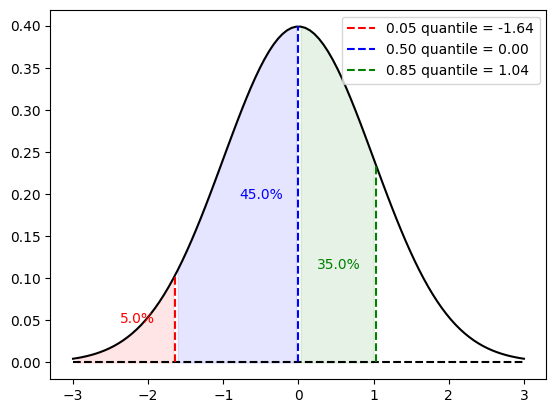

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-3, 3, 100)
plt.plot([-3, 3], [0, 0], 'k--')

y = norm.pdf(x)

plt.plot(x, y, 'k')

points = [
    (0.05, 'r'),
    (0.5, 'b'),
    (0.85, 'g'),
]
points = list((q, norm.ppf(q), c) for q, c in points)

handles = []

for i, (q, y, c) in enumerate(points):
    start = -3 if i == 0 else points[i-1][1]
    x_fill = x[(x <= y) & (x > start)]
    plt.fill_between(x_fill, norm.pdf(x_fill), color=c, alpha=0.1)
    handles.append(plt.plot([y, y], [0, norm.pdf(y)], c + '--', label=f'{q:.2f} quantile = {y:.2f}'))

    q_prev = 0 if i == 0 else points[i-1][0]
    plt.text(y - 0.5, norm.pdf(y) / 2, f'{(q - q_prev)*100}%', color=c, ha='center', va='center')


plt.legend()
plt.show()



## Quantile and expectile regression losses

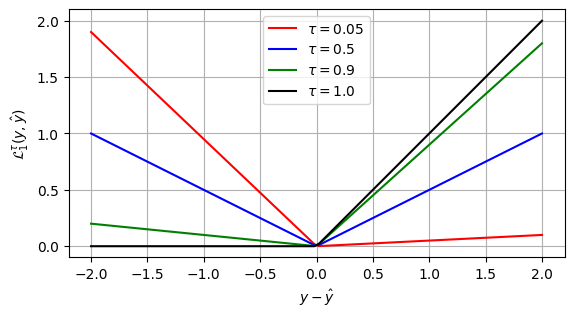

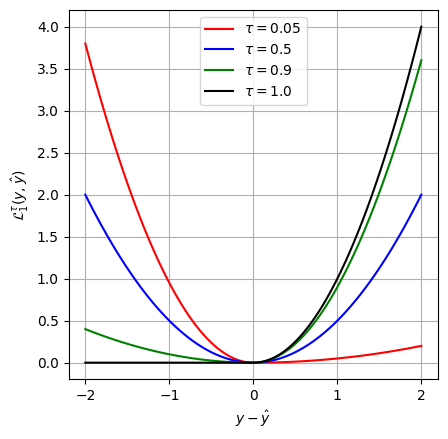

In [141]:
import torch

u = np.linspace(-2, 2, 100)

for tau, c in [(0.05, 'r'), (0.5, 'b'), (0.9, 'g'), (1.0, 'k')]:
    plt.plot(u, np.where(u < 0, (tau - 1) * u, tau * u), c, label=fr'$\tau = {tau}$')

plt.xlabel(r'$y - \hat{y}$')
plt.ylabel(r'${\cal L}_1^{\tau}(y, \hat{y})$')
plt.grid()
plt.legend()
plt.gca().set_aspect('equal')
plt.show()


for tau, c in [(0.05, 'r'), (0.5, 'b'), (0.9, 'g'), (1.0, 'k')]:
    plt.plot(u, np.where(u < 0, (1 - tau) * u ** 2, tau * u ** 2), c, label=fr'$\tau = {tau}$')

plt.xlabel(r'$y - \hat{y}$')
plt.ylabel(r'${\cal L}_1^{\tau}(y, \hat{y})$')
plt.grid()
plt.legend()
plt.gca().set_aspect('equal')
plt.show()


